In [1]:
import svgpathtools
from shapely.geometry import Polygon, Point, LineString
from shapely.ops import polygonize
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from xml.etree import ElementTree as ET
import json
import pickle

# Настройки шаблонов

In [2]:
def load_template_from_svg(svg_path):
    """
    Загружает шаблон из SVG, исправляет ориентацию и создает структуру данных
    
    Ожидаемая структура SVG:
    - Слой с суфиксом "_contour" - общий контур легкого
    - Остальные слои - сегменты
    - Группа "key_points" с точками внутри (круги 2x2)
    
    Parameters:
    - svg_path: путь к SVG файлу
    
    Returns:
    - template: словарь с ключами:
        * 'lung_contour': Polygon - контур легкого
        * 'segments': dict - словарь сегментов {Polygon}
        * 'key_points': dict - словарь ключевых точек {(x, y)}
        * 'all_polygons': list - все полигоны (для отладки)
        * 'bounds': (minx, miny, maxx, maxy) - границы шаблона
    """
    
    # Парсим XML для получения структуры групп
    tree = ET.parse(svg_path)
    root = tree.getroot()
    
    # Получаем все пути с их иерархией
    paths_data = []
    
    def extract_paths(element, group_path=None):
        if group_path is None:
            group_path = []
        
        for child in element:
            if child.tag.endswith('g'):
                group_id = child.get('id', '')
                new_path = group_path + [group_id]
                extract_paths(child, new_path)
            elif child.tag.endswith('path'):
                path_id = child.get('id', '')
                paths_data.append({
                    'id': path_id,
                    'group_path': group_path,
                    'depth': len(group_path)
                })
    
    extract_paths(root)

    # Загружаем SVG
    paths, attributes = svgpathtools.svg2paths(svg_path)
    
    # Собираем все полигоны
    all_polygons = {}
    
    for path, attr in zip(paths, attributes):
        name = attr.get('id', '')
        
        # Собираем точки
        points = []
        for segment in path:
            if hasattr(segment, 'start'):
                points.append((segment.start.real, segment.start.imag))
            if hasattr(segment, 'end') and segment.end not in points:
                points.append((segment.end.real, segment.end.imag))
        
        all_polygons[name] = Polygon(points)
    
    # Находим контур легкого
    lung_contour_name = [name for name in all_polygons.keys() if name.endswith('_contour')][0]
    lung_contour = all_polygons[lung_contour_name]
    print(f"  ✓ Найден контур легкого: '{lung_contour_name}'")
    
    # Формируем сегменты и ключевые точки
    segments = {}
    key_points = {}
    
    for name, poly in all_polygons.items():
        if name == lung_contour_name:
            continue
        
        # Находим данные о путях
        path_info = next((d for d in paths_data if d['id'] == name), None)
        
        if path_info and path_info['group_path']:
            last_group = path_info['group_path'][-1]
            
            if last_group == 'key_points':
                # Это ключевая точка — извлекаем её центр
                # Для маленького кружка центр — это среднее всех точек
                centroid = poly.centroid
                key_points[name] = (centroid.x, centroid.y)
                print(f"  ✓ Ключевая точка: {name} ({centroid.x:.1f}, {centroid.y:.1f})")
            else:
                # Это сегмент (в другой группе или без группы)
                segments[name] = poly
                print(f"  ✓ Сегмент: {name}")
    
    print(f"  ✓ Загружено сегментов: {len(segments)}")
    print(f"  ✓ Загружено ключевых точек: {len(key_points)}")
    
    # Инвертируем Y координаты
    all_polys = [lung_contour] + list(segments.values())
    
    min_y = min(min(p.exterior.xy[1]) for p in all_polys)
    max_y = max(max(p.exterior.xy[1]) for p in all_polys)
    
    image_height = max_y - min_y + 5
    
    def flip_y(x, y):
        return (x, image_height - y)
    
    # Инвертируем контур
    flipped_lung = Polygon([flip_y(x, y) for x, y in lung_contour.exterior.coords])
    
    # Инвертируем сегменты
    flipped_segments = {}
    for name, geom in segments.items():
        flipped_segments[name] = Polygon([flip_y(x, y) for x, y in geom.exterior.coords])
    
    # Инвертируем ключевые точки
    flipped_key_points = {}
    for name, (x, y) in key_points.items():
        flipped_key_points[name] = flip_y(x, y)
    
    # Собираем все для границ
    flipped_all = [flipped_lung]
    for geom in flipped_segments.values():
        flipped_all.append(geom)
    
    bounds = (
        min(min(p.exterior.xy[0]) for p in flipped_all),
        min(min(p.exterior.xy[1]) for p in flipped_all),
        max(max(p.exterior.xy[0]) for p in flipped_all),
        max(max(p.exterior.xy[1]) for p in flipped_all)
    )
    
    template = {
        'lung_contour': flipped_lung,
        'segments': flipped_segments,
        'key_points': flipped_key_points,
        'all_polygons': flipped_all,
        'bounds': bounds,
    }
    
    print(f"  ✓ Ориентация исправлена")
    print(f"  ✓ Границы: X [{bounds[0]:.0f}, {bounds[2]:.0f}], Y [{bounds[1]:.0f}, {bounds[3]:.0f}]")
    
    return template

In [6]:
def display_template(template, figsize=(12, 10), show_segment_names=True, 
                    show_key_points=True, lung_color='darkblue', alpha=0.5,
                    key_point_color='red', key_point_size=50):
    """
    Отображает загруженный шаблон

    Parameters:
    - template: словарь от load_template_from_svg
    - figsize: размер рисунка
    - show_segment_names: показывать названия сегментов
    - show_key_points: показывать ключевые точки
    - lung_color: цвет контура легкого
    - alpha: прозрачность заливки сегментов
    - key_point_color: цвет ключевых точек
    - key_point_size: размер ключевых точек
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Рисуем контур легкого
    if template['lung_contour']:
        x, y = template['lung_contour'].exterior.xy
        ax.plot(x, y, 'b-', linewidth=2, color=lung_color, label='Контур легкого')

    # Рисуем сегменты
    segments = template['segments']
    if segments:
        # Генерируем цвета
        colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

        for (name, geom), color in zip(sorted(segments.items()), colors):
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=alpha, color=color)
            ax.plot(x, y, 'k-', linewidth=0.8, alpha=0.7)

            if show_segment_names:
                # Подписываем каждую часть
                cx, cy = geom.centroid.x, geom.centroid.y
                ax.plot(cx, cy, 'ro', markersize=4)
                ax.text(cx, cy, name, fontsize=9, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

    # Рисуем ключевые точки
    if show_key_points and 'key_points' in template and template['key_points']:
        key_points = template['key_points']

        # Рисуем точки
        x_coords = [coord[0] for coord in key_points.values()]
        y_coords = [coord[1] for coord in key_points.values()]
        ax.scatter(x_coords, y_coords, c=key_point_color, s=key_point_size, 
                  zorder=5, label='Ключевые точки', edgecolors='white', linewidth=1)

        # Подписываем точки
        for name, (x, y) in key_points.items():
            ax.text(x, y + 15, name, fontsize=8, fontweight='bold', ha='center', va='bottom',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.8))

    # Настройки отображения
    bounds = template['bounds']
    ax.set_xlim(bounds[0] - 20, bounds[2] + 20)
    ax.set_ylim(bounds[1] - 20, bounds[3] + 20)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlabel('X (пиксели)')
    ax.set_ylabel('Y (пиксели)')

    
    # Статистика в заголовке
    ax.set_title(f'Шаблон: {len(segments)} сегментов, {len(template["key_points"])} ключевых точек', 
                fontsize=12, pad=20)

    plt.tight_layout()
    plt.show()

    # Список ключевых точек
    if template["key_points"]:
        print(f"\nКлючевые точки:")
        for name, (x, y) in template["key_points"].items():
            print(f"  {name}: ({x:.1f}, {y:.1f})")

  ✓ Найден контур легкого: 'right_lung_contour'
  ✓ Сегмент: R8
  ✓ Сегмент: R5
  ✓ Сегмент: R4
  ✓ Сегмент: R3
  ✓ Сегмент: R2
  ✓ Сегмент: R1
  ✓ Ключевая точка: diaphragm_dome (533.5, 1995.0)
  ✓ Ключевая точка: medial_lower (1007.5, 1690.0)
  ✓ Ключевая точка: lateral_lower (68.5, 2090.5)
  ✓ Ключевая точка: central_lung (483.5, 1046.0)
  ✓ Ключевая точка: medial_middle (1068.8, 1386.0)
  ✓ Ключевая точка: lateral_middle (4.5, 1386.0)
  ✓ Ключевая точка: medial_hilum_level (1103.0, 883.0)
  ✓ Ключевая точка: lateral_hilum_level (108.0, 882.0)
  ✓ Ключевая точка: hilum_angle (856.5, 883.0)
  ✓ Ключевая точка: medial_upper (1005.7, 442.5)
  ✓ Ключевая точка: lateral_upper (314.5, 440.5)
  ✓ Ключевая точка: apex (897.5, 1.0)
  ✓ Загружено сегментов: 6
  ✓ Загружено ключевых точек: 12
  ✓ Ориентация исправлена
  ✓ Границы: X [0, 1106], Y [4, 2110]


C:\Users\TTankrat\AppData\Local\Temp\ipykernel_19064\2327428322.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y, 'b-', linewidth=2, color=lung_color, label='Контур легкого')


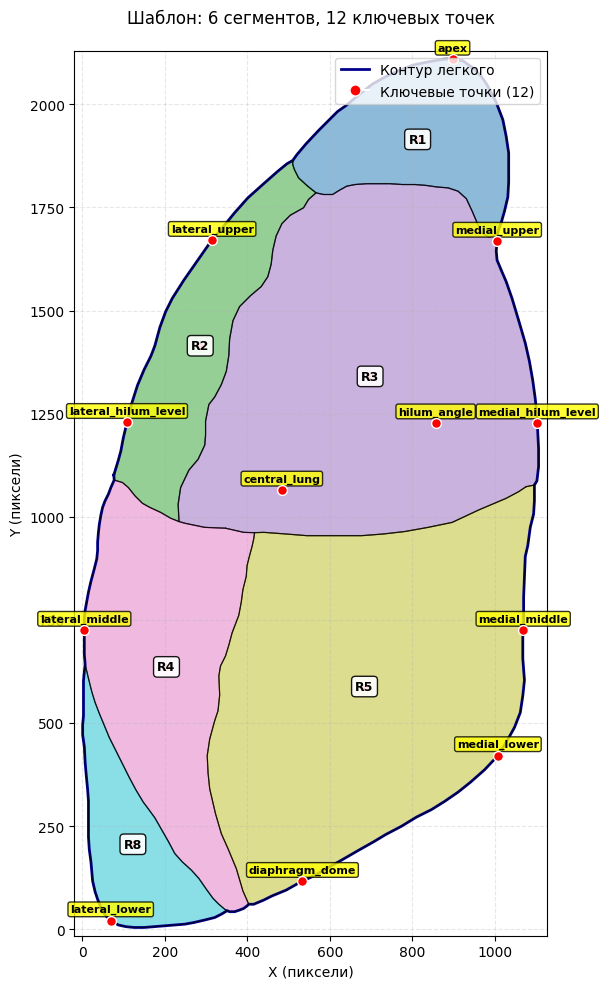


Ключевые точки:
  apex: (897.5, 2110.0)
  central_lung: (483.5, 1065.0)
  diaphragm_dome: (533.5, 116.0)
  hilum_angle: (856.5, 1228.0)
  lateral_hilum_level: (108.0, 1229.0)
  lateral_lower: (68.5, 20.5)
  lateral_middle: (4.5, 725.0)
  lateral_upper: (314.5, 1670.5)
  medial_hilum_level: (1103.0, 1228.0)
  medial_lower: (1007.5, 421.0)
  medial_middle: (1068.8, 725.0)
  medial_upper: (1005.7, 1668.5)


In [5]:
template = load_template_from_svg('Right_Lung_PA.svg')
display_template(template)